In [7]:
import wfdb
import neurokit2 as nk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

data_dir = 'data/mit-bih-arrhythmia-database-1.0.0'

In [8]:
# Load list of all available records
# Each notebook needs to define its own variables
with open(f'{data_dir}/RECORDS') as f:
    records = f.read().splitlines()

print(f'Total records: {len(records)}')

Total records: 48


In [9]:
# extract individual beat segments from all 48 records
# each segment is a window of 200 samples around one R peak
# this i the segmentation step - cutting the signal into individual beats

window = 100 # 100 samples before and after R peak
beats = [] # will store the signal segment for each beat
labels = [] # will store the label (N or abnormal) for ech beat

# define which symbols we consider abnormal
abnormal_symbols = {'L', 'R', 'V', 'A', 'F', 'f', 'E', 'e', 'j', 'J'}

for rec in records:
    try:
        # load signal and annotations
        record = wfdb.rdrecord(f'{data_dir}/{rec}')
        annotation = wfdb.rdann(f'{data_dir}/{rec}', 'atr')

        signal = record.p_signal[:, 0]
        fs = record.fs

        # clean the signal
        signal_clean = nk.ecg_clean(signal, sampling_rate=fs)

        # get annotation positions and symbols
        positions = annotation.sample
        symbols = annotation.symbol

        # extract window around each annotated beat
        for pos, sym in zip(positions, symbols):
            # skip if window goes out of bounds
            if pos - window < 0 or pos + window >= len(signal_clean):
                continue

            # skip non-beat annotations
            if sym not in abnormal_symbols and sym != 'N':
                continue

            # extract the beat segment
            beat = signal_clean[pos-window:pos+window]

            # label as normal or abnormal
            label = 'N' if sym == 'N' else 'A'

            beats.append(beat)
            labels.append(label)

    except Exception as e:
        print(f'Skipping record {rec}: {e}')

beats = np.array(beats)
labels = np.array(labels)

print(f'Total beats extracted: {len(beats)}')
print(f'Beat segment shape: {beats.shape}')
print(f'Label distribution: {Counter(labels)}')

Total beats extracted: 102251
Beat segment shape: (102251, 200)
Label distribution: Counter({np.str_('N'): 75028, np.str_('A'): 27223})


In [10]:
# encode labels to numbers - N=1, A=0
le = LabelEncoder()
y = le.fit_transform(labels)

# X is already our beat segments
X = beats

# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training beats: {len(X_train)}')
print(f'Test beats: {len(X_test)}')

# train random forest with class weights to handle imbalance
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced', # automatically handles imbalance
    random_state=42,
    n_jobs=1 # use all CPU cores to speed up training
)

model.fit(X_train, y_train)
print('Model trained')

Training beats: 81800
Test beats: 20451
Model trained


In [11]:
# evaluate the model
predictions = model.predict(X_test)

# classification report gives per-class precision, recall and f1
print(classification_report(y_test, predictions, target_names=le.classes_))

# overall accuracy
print(f'Overall accuracy: {accuracy_score(y_test, predictions):.4f}')

              precision    recall  f1-score   support

           A       0.99      0.96      0.98      5445
           N       0.99      1.00      0.99     15006

    accuracy                           0.99     20451
   macro avg       0.99      0.98      0.98     20451
weighted avg       0.99      0.99      0.99     20451

Overall accuracy: 0.9873


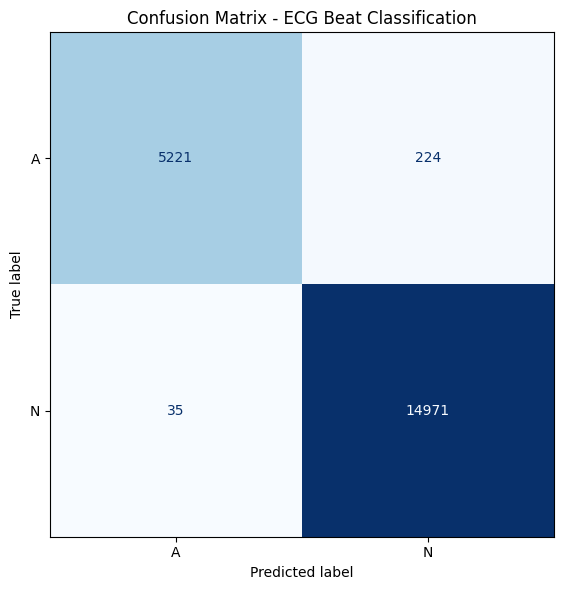

True Normal (correctly identified): 5221
False Abnormal (normal flagged as abnormal): 224
False Normal (abnormal missed): 35
True Abnormal (correctly identified): 14971


In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix - ECG Beat Classification')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Normal (correctly identified): {tn}')
print(f'False Abnormal (normal flagged as abnormal): {fp}')
print(f'False Normal (abnormal missed): {fn}')
print(f'True Abnormal (correctly identified): {tp}')

In [13]:
import joblib

# Save the trained model
joblib.dump(model, 'ecg_model.pkl')
print('Model saved')

Model saved
